<a href="https://www.kaggle.com/code/hrishikeshsoudagar/sentiment-analysis-on-tweets?scriptVersionId=303107806" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

Reading Dataset

In [2]:
df=pd.read_csv("/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv",encoding="latin-1")

Getting Info 

In [3]:
df.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


Changing Columns Name 

In [4]:
df.columns=['target','id','date','query','user','text']

In [5]:
df

,target,id,date,query,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
...,...,...,...,...,...,...
1599994,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599995,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599996,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599997,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


Selecting Required Columns 

In [6]:
df1= df[['target','text']]

In [7]:
df1

,target,text
0,0,is upset that he can't update his Facebook by ...
1,0,@Kenichan I dived many times for the ball. Man...
2,0,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all...."
4,0,@Kwesidei not the whole crew
...,...,...
1599994,4,Just woke up. Having no school is the best fee...
1599995,4,TheWDB.com - Very cool to hear old Walt interv...
1599996,4,Are you ready for your MoJo Makeover? Ask me f...
1599997,4,Happy 38th Birthday to my boo of alll time!!! ...


Ignoring Warnings

In [8]:
import warnings
warnings.filterwarnings("ignore")

Remapping The Target Variables

In [9]:
df1['target'] = df1['target'].replace({4:1})

In [10]:
df1

,target,text
0,0,is upset that he can't update his Facebook by ...
1,0,@Kenichan I dived many times for the ball. Man...
2,0,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all...."
4,0,@Kwesidei not the whole crew
...,...,...
1599994,1,Just woke up. Having no school is the best fee...
1599995,1,TheWDB.com - Very cool to hear old Walt interv...
1599996,1,Are you ready for your MoJo Makeover? Ask me f...
1599997,1,Happy 38th Birthday to my boo of alll time!!! ...


Importing Libraries For NLP 

In [11]:
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [12]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [13]:
def clean_text(text):
    text=text.lower()
    tokens=word_tokenize(text)
    
    cleaned_words=[]
    
    for word in tokens:
        if word.startswith("http"):
            continue
        if word.startswith("@"):
            continue
        if word in string.punctuation:
            continue
        if word not in stop_words:
            word=lemmatizer.lemmatize(word)
            cleaned_words.append(word)
            
    return " ".join(cleaned_words)

In [14]:
df1['clean_text'] = df1['text'].apply(clean_text)

Train Test Split

In [15]:
from sklearn.model_selection import train_test_split

Defining Feature & Target Variable 

In [16]:
x= df1['clean_text']
y= df1['target']

In [17]:
x

0          upset ca n't update facebook texting ... might...
1          kenichan dived many time ball managed save 50 ...
2                            whole body feel itchy like fire
3              nationwideclass 's behaving 'm mad ca n't see
4                                        kwesidei whole crew
                                 ...                        
1599994                        woke school best feeling ever
1599995    thewdb.com cool hear old walt interview â « /...
1599996                       ready mojo makeover ask detail
1599997    happy 38th birthday boo alll time tupac amaru ...
1599998    happy charitytuesday thenspcc sparkscharity sp...
Name: clean_text, Length: 1599999, dtype: object

In [18]:
y

0          0
1          0
2          0
3          0
4          0
          ..
1599994    1
1599995    1
1599996    1
1599997    1
1599998    1
Name: target, Length: 1599999, dtype: int64

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
x_train

1441334                      otavolimed second get back haha
1169011                                    race life awesome
1480550    's good clothes otherwise could even awkward a...
790714     late work week n't even take metro guess bus a...
1247006       selestina118 incredible people need know worry
                                 ...                        
259178                                        n't link wrong
1414414    tommcfly yes mcfly twitter profile excellent idea
131932     sarahftw know sometimes pretend superpower lik...
671155                           cant believe came asked ...
121958                                             back bali
Name: clean_text, Length: 1279999, dtype: object

In [21]:
y_train

1441334    1
1169011    1
1480550    1
790714     0
1247006    1
          ..
259178     0
1414414    1
131932     0
671155     0
121958     0
Name: target, Length: 1279999, dtype: int64

In [22]:
x_test

541200     nkluvr4eva poor little dumpling holmdel vids r...
750          'm bed got ta wake hella early tomorrow morning
766711                 havent able listen yet speaker busted
285055     remembers solving relatively big equation two ...
705995                                    ate much feel sick
                                 ...                        
839535                                      daniplq 's score
1023175    anybody anything exciting bank holiday weekend...
1349376                  interweavenews thanks link -is- rad
1086941    grounded weekend really ... dont care best sho...
158976                 watch drag hell baconfortress scurred
Name: clean_text, Length: 320000, dtype: object

In [23]:
y_test

541200     0
750        0
766711     0
285055     0
705995     0
          ..
839535     1
1023175    1
1349376    1
1086941    1
158976     0
Name: target, Length: 320000, dtype: int64

Feature Engineering

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [25]:
tfidf = TfidfVectorizer(max_features=10000,ngram_range=(1,2))

x_train_tfidf = tfidf.fit_transform(x_train)

x_test_tfidf = tfidf.transform(x_test)

Train Models 

Naive Bayes Model

In [26]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [27]:
nb = MultinomialNB()

nb.fit(x_train_tfidf,y_train)

nb_pred = nb.predict(x_test_tfidf)

print("Naive Bayes")

print("Accuracy:",accuracy_score(y_test,nb_pred)*100)
print("Precision:",precision_score(y_test,nb_pred)*100)
print("Recall:",recall_score(y_test,nb_pred)*100)
print("F1 Score:",f1_score(y_test,nb_pred)*100)

Naive Bayes
Accuracy: 76.373125
Precision: 76.77253749416617
Recall: 75.84077853787397
F1 Score: 76.3038136549407


Confusion Matrix Heatmap For Naive Bayes

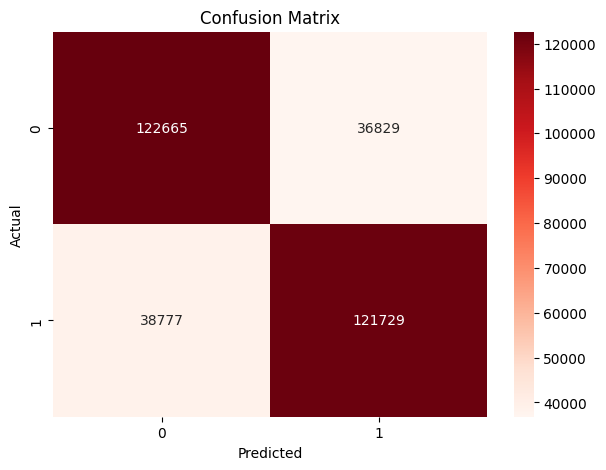

In [28]:
cm = confusion_matrix(y_test,nb_pred)

plt.figure(figsize=(7,5))

sns.heatmap(cm,annot=True,fmt="d",cmap="Reds")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Logistic Regression Model

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
lr=LogisticRegression(max_iter=10000)

lr.fit(x_train_tfidf,y_train)

lr_pred=lr.predict(x_test_tfidf)

print("Logistic Regression")

print("Accuracy:",accuracy_score(y_test,lr_pred)*100)
print("Precision:",precision_score(y_test,lr_pred)*100)
print("Recall:",recall_score(y_test,lr_pred)*100)
print("F1 Score:",f1_score(y_test,lr_pred)*100)

Logistic Regression
Accuracy: 78.2209375
Precision: 77.16333355268274
Recall: 80.36272787310132
F1 Score: 78.73054045723251


Confusion Matrix Heatmap For Logistic Regression 

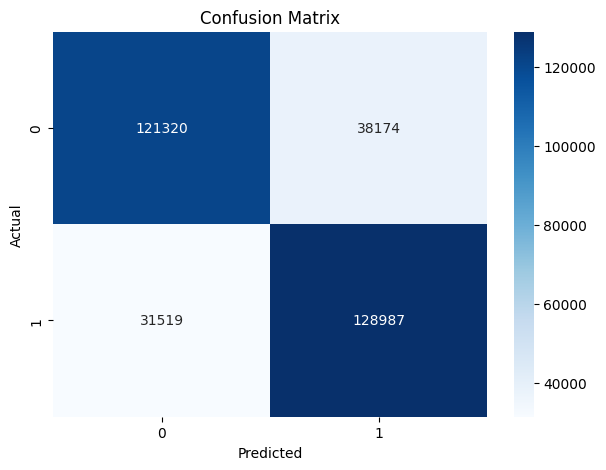

In [31]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(7,5))

sns.heatmap(cm, annot=True,fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Random Forest Model

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
rf=RandomForestClassifier(n_estimators=50,max_depth=20,random_state=40)

rf.fit(x_train_tfidf,y_train)

rf_pred=rf.predict(x_test_tfidf)

print("Random Forest Classifier")

print("Accuracy:",accuracy_score(y_test,rf_pred)*100)
print("Precision:",precision_score(y_test,rf_pred)*100)
print("Recall:",recall_score(y_test,rf_pred)*100)
print("F1 Score:",f1_score(y_test,rf_pred)*100)

Random Forest Classifier
Accuracy: 72.039375
Precision: 69.08149230636981
Recall: 80.10915479795148
F1 Score: 74.18776000046158


Confusion Matrix Heatmap For Random Forest Classifier

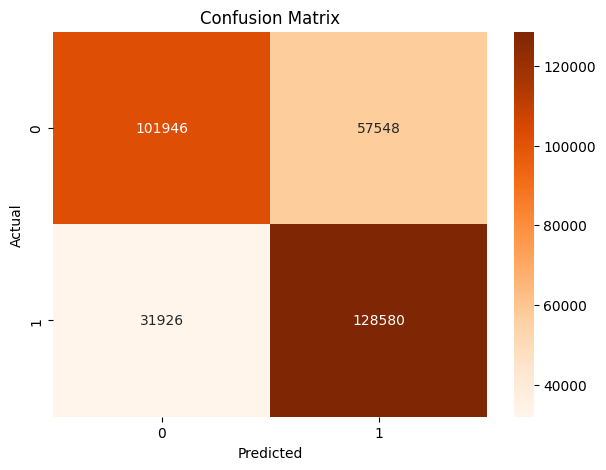

In [34]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7,5))

sns.heatmap(cm, annot=True,fmt="d", cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Wordcloud

In [35]:
from wordcloud import WordCloud

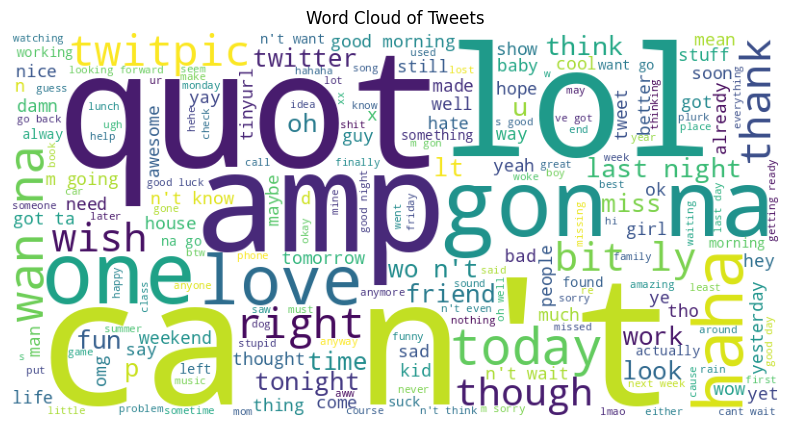

In [36]:
text = " ".join(df1["clean_text"])

wordcloud = WordCloud(width=800,height=400,background_color="white").generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud of Tweets")

plt.show()

Qualitative Evaluation

In [37]:
sample = pd.DataFrame({"Tweet": x_test[:10],"Actual": y_test[:10],"Predicted":lr_pred[:10]})
sample.tail()

,Tweet,Actual,Predicted
379611,tried purchase parked domain godaddy 70 drain ...,0,0
1189017,lunch .... dj come eat,1,1
667030,got back va tech equine medical center ... poo...,0,0
93541,ca n't log twitter account super bummed,0,0
1365937,tamaraschilling adventure 's need life glad gr...,1,1


Conclusion

- For the dataset Sentiment140.I performed sentiment analysis using TF-IDF vectorization and machine learning models such as Naive Bayes,Logistic Regression,and Random Forest.

- The Logistic Regression model achieved the best accuracy among the Naive Bayes and  Random Forest Classifier.

- The visualization technique such as confusion matrix heatmap helped understand the distribution of words and prediction performance on the dataset.

- The WordCloud being created gives the most common words being used in tweets.